# 2026 COMP90042 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
!pip install nltk contractions rank_bm25 --quiet

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

nltk.download('wordnet', quiet=True)   # ← ADD THIS
nltk.download('averaged_perceptron_tagger_eng', quiet=True)  # ← ADD THIS

print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
Done.


In [ ]:
import json
import os
TRAIN_PATH    = 'train-claims.json'
DEV_PATH      = 'dev-claims.json'
TEST_PATH     = 'test-claims-unlabelled.json'
EVIDENCE_PATH = 'evidence.json'

OUTPUT_DIR    = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Confirm files exist
for name, path in [
    ('train-claims',         TRAIN_PATH),
    ('dev-claims',           DEV_PATH),
    ('test-claims',          TEST_PATH),
    ('evidence',             EVIDENCE_PATH),
]:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {status}  {name}')

# Load all files
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

print('\nLoading train-claims...')
train_claims = load_json(TRAIN_PATH)

print('Loading dev-claims...')
dev_claims = load_json(DEV_PATH)

print('Loading test-claims...')
test_claims = load_json(TEST_PATH)

print('Loading evidence (may take ~60s)...')
evidence = load_json(EVIDENCE_PATH)

print('\nAll loaded.')
print(f'  Train claims : {len(train_claims):,}')
print(f'  Dev claims   : {len(dev_claims):,}')
print(f'  Test claims  : {len(test_claims):,}')
print(f'  Evidence     : {len(evidence):,}')

  ✓  train-claims
  ✓  dev-claims
  ✓  test-claims
  ✓  evidence

Loading train-claims...
Loading dev-claims...
Loading test-claims...
Loading evidence (may take ~60s)...

All loaded.
  Train claims : 1,228
  Dev claims   : 154
  Test claims  : 153
  Evidence     : 1,208,827


In [ ]:
# Check A — print one sample from each
print('=== Sample train claim ===')
sample_key = list(train_claims.keys())[0]
print(json.dumps(train_claims[sample_key], indent=2))

print('\n=== Sample evidence passage ===')
ev_key = list(evidence.keys())[0]
print(f'{ev_key}: {evidence[ev_key]}')

# Check B — required fields
REQUIRED = {'claim_text', 'claim_label', 'evidences'}
errors = []
for cid, entry in train_claims.items():
    missing = REQUIRED - set(entry.keys())
    if missing:
        errors.append(f'{cid} missing: {missing}')
if errors:
    print(f'\n✗ {len(errors)} claims missing fields')
    for e in errors[:5]:
        print(f'  {e}')
else:
    print('\n✓ All train claims have required fields')

# Check C — evidence IDs valid
evidence_ids = set(evidence.keys())
missing_ids = 0
for cid, entry in train_claims.items():
    for eid in entry.get('evidences', []):
        if eid not in evidence_ids:
            missing_ids += 1
if missing_ids:
    print(f'✗ {missing_ids} evidence IDs not found in evidence.json')
else:
    print('✓ All evidence IDs valid')

=== Sample train claim ===
{
  "claim_text": "Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.",
  "claim_label": "DISPUTED",
  "evidences": [
    "evidence-442946",
    "evidence-1194317",
    "evidence-12171"
  ]
}

=== Sample evidence passage ===
evidence-0: John Bennet Lawes, English entrepreneur and agricultural scientist

✓ All train claims have required fields
✓ All evidence IDs valid



Train class distribution (total=1228):
  SUPPORTS            :   519  (42.3%)
  REFUTES             :   199  (16.2%)
  NOT_ENOUGH_INFO     :   386  (31.4%)
  DISPUTED            :   124  (10.1%)

Dev class distribution (total=154):
  SUPPORTS            :    68  (44.2%)
  REFUTES             :    27  (17.5%)
  NOT_ENOUGH_INFO     :    41  (26.6%)
  DISPUTED            :    18  (11.7%)


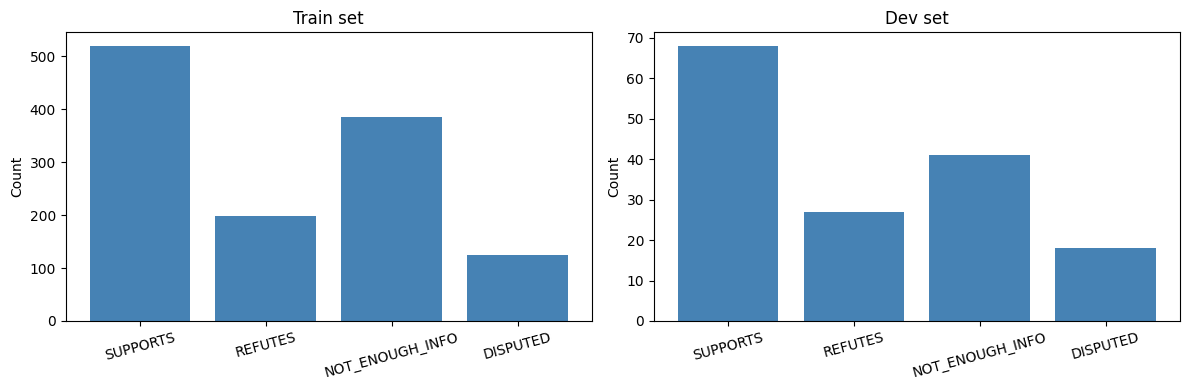


Claim length (words):
  Min    : 4
  Max    : 67
  Mean   : 20.1
  Median : 19.0

Evidence passage length distribution:
  ≤5 words       :   13,578
  6–10 words     :  180,771
  11–20 words    :  547,481
  21–50 words    :  451,498
  51–100 words   :   15,217
  100+ words     :      282

Gold evidences per claim:
  Min    : 1
  Max    : 5
  Mean   : 3.4


In [ ]:
import collections
import numpy as np
import matplotlib.pyplot as plt

# ── Class distribution ──
LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']

def class_distribution(dataset, name):
    counts = collections.Counter(
        v['claim_label'] for v in dataset.values()
    )
    total = sum(counts.values())
    print(f'\n{name} class distribution (total={total}):')
    for label in LABELS:
        n = counts.get(label, 0)
        print(f'  {label:<20}: {n:>5}  ({100*n/total:.1f}%)')
    return counts

train_counts = class_distribution(train_claims, 'Train')
dev_counts   = class_distribution(dev_claims,   'Dev')

# ── Plot class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (counts, title) in zip(axes, [
    (train_counts, 'Train set'),
    (dev_counts,   'Dev set'),
]):
    vals = [counts.get(l, 0) for l in LABELS]
    ax.bar(LABELS, vals, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

# ── Claim length distribution ──
claim_lengths = [
    len(v['claim_text'].split())
    for v in train_claims.values()
]
print(f'\nClaim length (words):')
print(f'  Min    : {np.min(claim_lengths)}')
print(f'  Max    : {np.max(claim_lengths)}')
print(f'  Mean   : {np.mean(claim_lengths):.1f}')
print(f'  Median : {np.median(claim_lengths):.1f}')

# ── Evidence length distribution ──
ev_lengths = [len(text.split()) for text in evidence.values()]
buckets = {
    '≤5 words'    : sum(1 for l in ev_lengths if l <= 5),
    '6–10 words'  : sum(1 for l in ev_lengths if 6 <= l <= 10),
    '11–20 words' : sum(1 for l in ev_lengths if 11 <= l <= 20),
    '21–50 words' : sum(1 for l in ev_lengths if 21 <= l <= 50),
    '51–100 words': sum(1 for l in ev_lengths if 51 <= l <= 100),
    '100+ words'  : sum(1 for l in ev_lengths if l > 100),
}
print('\nEvidence passage length distribution:')
for bucket, count in buckets.items():
    print(f'  {bucket:<15}: {count:>8,}')

# ── Evidences per claim ──
ev_per_claim = [
    len(v['evidences']) for v in train_claims.values()
]
print(f'\nGold evidences per claim:')
print(f'  Min    : {np.min(ev_per_claim)}')
print(f'  Max    : {np.max(ev_per_claim)}')
print(f'  Mean   : {np.mean(ev_per_claim):.1f}')

In [ ]:
import re
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer   # ← ADD THIS IMPORT
from nltk.corpus import wordnet           # ← ADD THIS IMPORT
import nltk                               # ← ADD THIS IMPORT

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()          # ← ADD THIS — create once outside the function


# ── Helper: convert NLTK POS tag → WordNet POS tag ──────────────────────
# WordNetLemmatizer only understands four POS categories: noun (n),
# verb (v), adjective (a), adverb (r). NLTK's tagger returns tags like
# 'NN', 'VBZ', 'JJ', 'RB'. This function maps between the two systems.
# If the tag is unrecognised, we default to noun — the safest fallback.
def get_wordnet_pos(nltk_tag):              # ← ADD THIS FUNCTION
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN               # default: treat as noun


def clean_text(text):
    # Guard against empty or non-string input
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []

    # 1. Expand contractions — wrapped in try/except
    #    because the contractions library crashes on some
    #    very short or unusual strings in the evidence corpus
    try:
        text = contractions.fix(text)
    except Exception:
        pass  # if it fails, just keep the original text

    # 2. Lowercase
    text = text.lower()

    # 3. Remove punctuation and special characters
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 4. Tokenise
    tokens = word_tokenize(text)

    # 5. Remove stopwords
    tokens = [t for t in tokens if t not in STOPWORDS]

    # 6. Remove empty or single-character tokens
    tokens = [t for t in tokens if len(t) > 1]

    # 7. POS-tag then lemmatise                        ← ADD STEPS 7 AND 8
    #    pos_tag returns pairs like [('warming', 'VBG'), ('temperatures', 'NNS')]
    #    We map each NLTK tag to WordNet format, then lemmatise accordingly.
    pos_tags = nltk.pos_tag(tokens)
    tokens = [
        lemmatizer.lemmatize(token, get_wordnet_pos(tag))
        for token, tag in pos_tags
    ]                                                   # ← END OF NEW BLOCK

    return tokens


# ── Test it ──────────────────────────────────────────────────────────────
test_sentence = "The Earth's climate isn't changing rapidly, according to some scientists."
print('Raw    :', test_sentence)
print('Cleaned:', clean_text(test_sentence))

# Show that lemmatisation is working
demo = "Temperatures are warming and glaciers are melting rapidly."
print('\nLemmatisation demo:')
print('Raw    :', demo)
print('Cleaned:', clean_text(demo))
# Expected: ['temperature', 'warm', 'glacier', 'melt', 'rapidly'] or similar

# Test edge cases
print('\nEmpty  :', clean_text(''))
print('Number :', clean_text('42'))
print('Short  :', clean_text('a'))

Raw    : The Earth's climate isn't changing rapidly, according to some scientists.
Cleaned: ['earth', 'climate', 'change', 'rapidly', 'accord', 'scientist']

Lemmatisation demo:
Raw    : Temperatures are warming and glaciers are melting rapidly.
Cleaned: ['temperature', 'warm', 'glacier', 'melt', 'rapidly']

Empty  : []
Number : ['42']
Short  : []


In [ ]:
def clean_claims(dataset):
    cleaned = {}
    for cid, entry in dataset.items():
        cleaned[cid] = {
            **entry,
            'clean_tokens': clean_text(entry['claim_text'])
        }
    return cleaned

print('Cleaning train claims...')
train_clean = clean_claims(train_claims)

print('Cleaning dev claims...')
dev_clean = clean_claims(dev_claims)

print('Cleaning test claims...')
test_clean = clean_claims(test_claims)

# Verify
sample = list(train_clean.values())[0]
print('\nSample:')
print('  Raw    :', sample['claim_text'])
print('  Tokens :', sample['clean_tokens'])

Cleaning train claims...
Cleaning dev claims...
Cleaning test claims...

Sample:
  Raw    : Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
  Tokens : ['scientific', 'evidence', 'co2', 'pollutant', 'high', 'co2', 'concentration', 'actually', 'help', 'ecosystems', 'support', 'plant', 'animal', 'life']


In [ ]:
evidence_clean = {}

total = len(evidence)
for i, (eid, text) in enumerate(evidence.items()):
    evidence_clean[eid] = clean_text(text)
    if (i + 1) % 200000 == 0:
        print(f'  Processed {i+1:,} / {total:,}')

print(f'Done. Total cleaned: {len(evidence_clean):,}')

# Verify
sample_eid = list(evidence.keys())[0]
print('\nSample:')
print('  Raw    :', evidence[sample_eid])
print('  Tokens :', evidence_clean[sample_eid])

  Processed 200,000 / 1,208,827
  Processed 400,000 / 1,208,827
  Processed 600,000 / 1,208,827
  Processed 800,000 / 1,208,827
  Processed 1,000,000 / 1,208,827
  Processed 1,200,000 / 1,208,827
Done. Total cleaned: 1,208,827

Sample:
  Raw    : John Bennet Lawes, English entrepreneur and agricultural scientist
  Tokens : ['john', 'bennet', 'lawes', 'english', 'entrepreneur', 'agricultural', 'scientist']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

LABEL2ID = {
    'SUPPORTS': 0, 'REFUTES': 1,
    'NOT_ENOUGH_INFO': 2, 'DISPUTED': 3
}

def build_input(claim_entry):
    # Combine claim text + all gold evidence texts into one string
    claim_text = claim_entry['claim_text']
    gold_ev_texts = [
        evidence.get(eid, '') for eid in claim_entry.get('evidences', [])
    ]
    return claim_text + ' ' + ' '.join(gold_ev_texts)

# Build train inputs
train_texts  = [build_input(v) for v in train_claims.values()]
train_labels = [LABEL2ID[v['claim_label']] for v in train_claims.values()]

# Build dev inputs
dev_texts  = [build_input(v) for v in dev_claims.values()]
dev_labels = [LABEL2ID[v['claim_label']] for v in dev_claims.values()]

# TF-IDF vectorise + logistic regression
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_texts)
X_dev   = vectorizer.transform(dev_texts)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, train_labels)

oracle_acc = accuracy_score(dev_labels, clf.predict(X_dev))
print(f'Oracle accuracy (gold evidence → dev): {oracle_acc:.4f}')
print('This is the classification ceiling.')
print('If final system is far below this, the bottleneck is retrieval.')

Oracle accuracy (gold evidence → dev): 0.5000
This is the classification ceiling.
If final system is far below this, the bottleneck is retrieval.


In [ ]:
def save_json(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False)
    print(f'  Saved: {path}')

# Save cleaned claims (tokens added as new field)
save_json(train_clean, os.path.join(OUTPUT_DIR, 'train_clean.json'))
save_json(dev_clean,   os.path.join(OUTPUT_DIR, 'dev_clean.json'))
save_json(test_clean,  os.path.join(OUTPUT_DIR, 'test_clean.json'))

# Save cleaned evidence tokens
save_json(evidence_clean, os.path.join(OUTPUT_DIR, 'evidence_clean.json'))

# Save a summary of key stats
summary = {
    'train_count'     : len(train_claims),
    'dev_count'       : len(dev_claims),
    'test_count'      : len(test_claims),
    'evidence_count'  : len(evidence),
    'train_class_dist': dict(train_counts),
    'dev_class_dist'  : dict(dev_counts),
    'oracle_accuracy' : round(oracle_acc, 4),
    'mean_claim_length'      : round(float(np.mean(claim_lengths)), 1),
    'mean_evidences_per_claim': round(float(np.mean(ev_per_claim)), 1),
    'evidence_length_buckets' : buckets,
}
save_json(summary, os.path.join(OUTPUT_DIR, 'stats_summary.json'))

print('\nAll outputs saved to:', OUTPUT_DIR)
print('\nTell your teammates:')
print('  BM25 retrieval  → load evidence_clean.json (tokens)')
print('  Transformer     → load original evidence.json (raw text)')

  Saved: preprocessed/train_clean.json
  Saved: preprocessed/dev_clean.json
  Saved: preprocessed/test_clean.json
  Saved: preprocessed/evidence_clean.json
  Saved: preprocessed/stats_summary.json

All outputs saved to: preprocessed

Tell your teammates:
  BM25 retrieval  → load evidence_clean.json (tokens)
  Transformer     → load original evidence.json (raw text)


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
import json
import numpy as np
from rank_bm25 import BM25Okapi

EVIDENCE_CLEAN_PATH = 'evidence_clean.json'
DEV_CLEAN_PATH = 'dev_clean.json'
DEV_RAW_PATH = 'dev-claims.json'

with open(EVIDENCE_CLEAN_PATH, 'r', encoding='utf-8') as f:
  evidence_clean = json.load(f)
evidence_ids = list(evidence_clean.keys())
tokenized_corpus = list(evidence_clean.values())
with open(DEV_CLEAN_PATH, 'r', encoding='utf-8') as f:
  dev_claims_clean = json.load(f)
with open(DEV_RAW_PATH, 'r', encoding='utf-8') as f:
  dev_claims_raw = json.load(f)
dev_claims_subset = dev_claims_clean

In [ ]:
def evaluate_retrieval(predictions, ground_truth):
    f_scores = []
    precisions = []
    recalls = []

    for claim_id, pred_data in predictions.items():
        pred_evidences = set(pred_data['evidences'])
        actual_evidences = set(ground_truth[claim_id].get('evidences', []))

        if len(pred_evidences) == 0:
            precision = 0
        else:
            precision = len(pred_evidences.intersection(actual_evidences)) / len(pred_evidences)

        if len(actual_evidences) == 0:
            recall = 0
        else:
            recall = len(pred_evidences.intersection(actual_evidences)) / len(actual_evidences)

        if precision + recall == 0:
            f1 = 0
        else:
            f1 = 2 * precision * recall / (precision + recall)

        precisions.append(precision)
        recalls.append(recall)
        f_scores.append(f1)

    return np.mean(precisions), np.mean(recalls), np.mean(f_scores)

# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
best_recall = 0
# revision
best_params = {}

k1_range = [0.5, 0.8, 1.2, 1.5]
b_range = [0.6, 0.75, 0.85, 0.9]
top_k_range = [10, 15, 20]

results = []

for top_k in top_k_range:
    for k1_val in k1_range:
        for b_val in b_range:
            print(f"\nTesting top_k={top_k}, k1={k1_val}, b={b_val}")

            bm25_model = BM25Okapi(tokenized_corpus, k1=k1_val, b=b_val)

            predictions = {}

            for claim_id, data in dev_claims_subset.items():
                query_tokens = data['clean_tokens']
                scores = bm25_model.get_scores(query_tokens)

                top_k_indices = np.argsort(scores)[-top_k:][::-1]

                predictions[claim_id] = {
                    "claim_label": "NOT_ENOUGH_INFO",
                    "evidences": [evidence_ids[idx] for idx in top_k_indices]
                }

            precision, recall, f1 = evaluate_retrieval(predictions, dev_claims_raw)

            print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

            results.append({
                "top_k": top_k,
                "k1": k1_val,
                "b": b_val,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })

            if recall > best_recall:
              best_recall = recall
              best_params = {"top_k": top_k, "k1": k1_val, "b": b_val}


print("\nBest parameters:")
print(best_params)
print(f"Best recall: {best_recall:.4f}")


Testing top_k=10, k1=0.5, b=0.6
Precision: 0.0786, Recall: 0.2751, F1: 0.1161

Testing top_k=10, k1=0.5, b=0.75
Precision: 0.0799, Recall: 0.2844, F1: 0.1184

Testing top_k=10, k1=0.5, b=0.85
Precision: 0.0792, Recall: 0.2808, F1: 0.1173

Testing top_k=10, k1=0.5, b=0.9
Precision: 0.0766, Recall: 0.2685, F1: 0.1133

Testing top_k=10, k1=0.8, b=0.6
Precision: 0.0779, Recall: 0.2787, F1: 0.1155

Testing top_k=10, k1=0.8, b=0.75
Precision: 0.0766, Recall: 0.2671, F1: 0.1131

Testing top_k=10, k1=0.8, b=0.85
Precision: 0.0747, Recall: 0.2580, F1: 0.1102

Testing top_k=10, k1=0.8, b=0.9
Precision: 0.0721, Recall: 0.2473, F1: 0.1064

Testing top_k=10, k1=1.2, b=0.6
Precision: 0.0766, Recall: 0.2675, F1: 0.1131

Testing top_k=10, k1=1.2, b=0.75
Precision: 0.0721, Recall: 0.2464, F1: 0.1062

Testing top_k=10, k1=1.2, b=0.85
Precision: 0.0682, Recall: 0.2347, F1: 0.1006

Testing top_k=10, k1=1.2, b=0.9
Precision: 0.0662, Recall: 0.2248, F1: 0.0975

Testing top_k=10, k1=1.5, b=0.6
Precision: 0.

In [ ]:
from tqdm import tqdm
bm25_model = BM25Okapi(tokenized_corpus, k1=0.5, b=0.6)  # best recall params
TOP_K = 20
def generate_bm25_dataset(clean_file_path, output_file_path, model, top_k):
  print(f"process: {clean_file_path}")
  with open(clean_file_path, 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
  predictions = {}
  file_name = clean_file_path.split('/')[-1]
  for claim_id, data in tqdm(data_dict.items(), desc=f"process {file_name}"):
    query_tokens = data['clean_tokens']
    scores = model.get_scores(query_tokens)
    top_k_indices = np.argsort(scores)[-top_k:][::-1]

    predictions[claim_id] = {
      "claim_label": "NOT_ENOUGH_INFO",
      "evidences": [evidence_ids[idx] for idx in top_k_indices]
    }

  with open(output_file_path, 'w', encoding='utf-8') as f:
        json.dump(predictions, f, indent=4)
  print(f"success: {output_file_path}")

generate_bm25_dataset(
  clean_file_path='dev_clean.json',
  output_file_path='bm25_dev_predictions.json',
  model=bm25_model,
  top_k=TOP_K
)

generate_bm25_dataset(
  clean_file_path='train_clean.json',
  output_file_path='bm25_train_predictions.json',
  model=bm25_model,
  top_k=TOP_K
)

generate_bm25_dataset(
  clean_file_path='test_clean.json',
  output_file_path='bm25_test_predictions.json',
  model=bm25_model,
  top_k=TOP_K
)

process: dev_clean.json


process dev_clean.json: 100%|██████████| 154/154 [17:01<00:00,  6.63s/it]


success: bm25_dev_predictions.json
process: train_clean.json


process train_clean.json: 100%|██████████| 1228/1228 [2:12:42<00:00,  6.48s/it]


success: bm25_train_predictions.json
process: test_clean.json


process test_clean.json: 100%|██████████| 153/153 [16:19<00:00,  6.40s/it]

success: bm25_test_predictions.json


In [ ]:
!python eval.py --predictions bm25_dev_predictions.json --groundtruth dev-claims.json

Evidence Retrieval F-score (F)    = 0.0872728617138555
Claim Classification Accuracy (A) = 0.2662337662337662
Harmonic Mean of F and A          = 0.1314542971880068


In [6]:
!pip install sentence-transformers --quiet
import json, random
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader

In [13]:
with open('train-claims.json') as f:
    train_claims = json.load(f)
with open('bm25_train_predictions.json') as f:
    bm25_train = json.load(f)
with open('bm25_dev_predictions.json') as f:
    bm25_dev = json.load(f)
with open('dev-claims.json') as f:
    dev_claims = json.load(f)
with open('evidence.json') as f:
    evidence_db = json.load(f)

print(f"Train claims: {len(train_claims)}")
print(f"Evidence passages: {len(evidence_db)}")

Train claims: 1228
Evidence passages: 1208827


In [ ]:
MAX_NEG_RATIO = 5
random.seed(42)

train_samples = []
for claim_id, item in train_claims.items():
    claim_text = item['claim_text']
    gold_ids = set(item['evidences'])

    if claim_id not in bm25_train:
        continue
    bm25_ids = bm25_train[claim_id]['evidences']

    positives = []
    for eid in gold_ids:
        if eid in evidence_db:
            positives.append(InputExample(texts=[claim_text, evidence_db[eid]], label=1.0))

    negatives = []
    for eid in bm25_ids:
        if eid not in gold_ids and eid in evidence_db:
            negatives.append(InputExample(texts=[claim_text, evidence_db[eid]], label=0.0))

    max_neg = len(positives) * MAX_NEG_RATIO
    if len(negatives) > max_neg:
        negatives = random.sample(negatives, max_neg)

    train_samples.extend(positives)
    train_samples.extend(negatives)

random.shuffle(train_samples)
n_pos = sum(1 for s in train_samples if s.label == 1.0)
n_neg = sum(1 for s in train_samples if s.label == 0.0)
print(f"Total pairs: {len(train_samples)}  ({n_pos} positive, {n_neg} negative, ratio 1:{n_neg//max(n_pos,1)})")

Total pairs: 21634  (4122 positive, 17512 negative, ratio 1:4)


In [ ]:
model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', num_labels=1, max_length=512)
train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=16)
warmup_steps = int(len(train_dataloader) * 3 * 0.1)

model.fit(
    train_dataloader=train_dataloader,
    epochs=3,
    warmup_steps=warmup_steps,
    output_path='finetuned_reranker',
    show_progress_bar=True,
)
print("Done. Model saved to finetuned_reranker/")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Step,Training Loss
500,0.617377
1000,0.389090
1500,0.349304
2000,0.302949
2500,0.284212
3000,0.264478
3500,0.242889
4000,0.240646


Done. Model saved to finetuned_reranker/


In [ ]:
model.save('./finetuned_reranker')
print(os.listdir('./finetuned_reranker'))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['model.safetensors', 'config_sentence_transformers.json', 'README.md', 'tokenizer.json', 'sentence_bert_config.json', 'modules.json', 'config.json', 'tokenizer_config.json']


In [4]:
# Unzip the model folder
!unzip fine_tuned_reranker.zip -d /content/
print("Model folder ready.")

Archive:  fine_tuned_reranker.zip
   creating: /content/fine_tuned_reranker/
  inflating: /content/fine_tuned_reranker/model.safetensors  
  inflating: /content/__MACOSX/fine_tuned_reranker/._model.safetensors  
  inflating: /content/fine_tuned_reranker/tokenizer_config.json  
  inflating: /content/__MACOSX/fine_tuned_reranker/._tokenizer_config.json  
  inflating: /content/fine_tuned_reranker/config.json  
  inflating: /content/__MACOSX/fine_tuned_reranker/._config.json  
  inflating: /content/fine_tuned_reranker/config_sentence_transformers.json  
  inflating: /content/__MACOSX/fine_tuned_reranker/._config_sentence_transformers.json  
  inflating: /content/fine_tuned_reranker/tokenizer.json  
  inflating: /content/__MACOSX/fine_tuned_reranker/._tokenizer.json  
  inflating: /content/fine_tuned_reranker/README (2).md  
  inflating: /content/__MACOSX/fine_tuned_reranker/._README (2).md  
  inflating: /content/fine_tuned_reranker/sentence_bert_config.json  
  inflating: /content/__MACOS

In [7]:
reranker = CrossEncoder('./finetuned_reranker', max_length=512)
print("Fine-tuned reranker loaded.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Fine-tuned reranker loaded.


In [8]:
def rerank(claim_text, candidate_ids, reranker, evidence_db, top_k=3):
    pairs, valid_ids = [], []
    for eid in candidate_ids:
        if eid in evidence_db:
            pairs.append([claim_text, evidence_db[eid]])
            valid_ids.append(eid)
    if not pairs:
        return candidate_ids[:top_k]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(valid_ids, scores), key=lambda x: x[1], reverse=True)
    return [eid for eid, _ in ranked[:top_k]]

In [14]:
reranked_train = {}
for claim_id, item in train_claims.items():
    if claim_id not in bm25_train:
        continue
    top3 = rerank(item['claim_text'], bm25_train[claim_id]['evidences'], reranker, evidence_db)
    reranked_train[claim_id] = {
        'claim_label': item['claim_label'],
        'evidences': top3
    }

with open('reranked_train_predictions.json', 'w') as f:
    json.dump(reranked_train, f, indent=2)
print(f"Saved reranked_train_predictions.json — {len(reranked_train)} claims")

KeyboardInterrupt: 

In [ ]:
reranked_dev = {}
for claim_id, item in bm25_dev.items():
    claim_text = dev_claims[claim_id]['claim_text']
    top3 = rerank(claim_text, item['evidences'], reranker, evidence_db)
    reranked_dev[claim_id] = {
        'claim_label': item['claim_label'],
        'evidences': top3
    }

with open('reranked_dev_predictions.json', 'w') as f:
    json.dump(reranked_dev, f, indent=2)
print(f"Saved reranked_dev_predictions.json — {len(reranked_dev)} claims")

Saved reranked_dev_predictions.json — 154 claims


In [ ]:
sample_id = list(bm25_dev.keys())[0]
print(f"Claim:          {dev_claims[sample_id]['claim_text'][:80]}...")
print(f"BM25 top-3:     {bm25_dev[sample_id]['evidences'][:3]}")
print(f"Reranked top-3: {reranked_dev[sample_id]['evidences']}")

Claim:          [South Australia] has the most expensive electricity in the world....
BM25 top-3:     ['evidence-67732', 'evidence-407584', 'evidence-780332']
Reranked top-3: ['evidence-572512', 'evidence-67732', 'evidence-472012']


In [3]:
# Unzip the model folder
!unzip classifier_model_3.zip -d /content/
print("Model folder ready.")

Archive:  classifier_model_3.zip
   creating: /content/classifier_model_3/
  inflating: /content/__MACOSX/._classifier_model_3  
  inflating: /content/classifier_model_3/model.safetensors  
  inflating: /content/__MACOSX/classifier_model_3/._model.safetensors  
  inflating: /content/classifier_model_3/rng_state.pth  
  inflating: /content/__MACOSX/classifier_model_3/._rng_state.pth  
  inflating: /content/classifier_model_3/tokenizer_config.json  
  inflating: /content/__MACOSX/classifier_model_3/._tokenizer_config.json  
  inflating: /content/classifier_model_3/config.json  
  inflating: /content/__MACOSX/classifier_model_3/._config.json  
  inflating: /content/classifier_model_3/scheduler.pt  
  inflating: /content/__MACOSX/classifier_model_3/._scheduler.pt  
  inflating: /content/classifier_model_3/tokenizer.json  
  inflating: /content/__MACOSX/classifier_model_3/._tokenizer.json  
  inflating: /content/classifier_model_3/training_args.bin  
  inflating: /content/__MACOSX/classifie

In [15]:
# ── Cell B: Verify all required files ───────────────────────────────────
from pathlib import Path

required = [
    'reranked_dev_predictions.json',
    'dev-claims.json',
    'evidence.json',
    'classifier_3.py',
    'classifier_model_3/config.json',
]
for f in required:
    status = '✅' if Path(f).exists() else '❌ MISSING'
    print(f"{status}  {f}")

✅  reranked_dev_predictions.json
✅  dev-claims.json
✅  evidence.json
✅  classifier_3.py
✅  classifier_model_3/config.json


In [21]:
# classifier_1.py has two hardcoded paths that need to point
# to the correct locations in your Colab environment

with open('classifier_3.py', 'r') as f:
    src = f.read()

src = src.replace(
    'Path("classifier_model_3")',
    'Path("classifier_model_3")'          # already correct if you're in PROJECT_DIR
).replace(
    'Path("data/evidence.json")',
    'Path("evidence.json")'               # evidence.json is in root, not data/
)

with open('classifier_3.py', 'w') as f:
    f.write(src)

print("Paths fixed. classifier_3.py is ready.")

Paths fixed. classifier_3.py is ready.


In [22]:
# Only needed if running in a fresh Colab session
!pip install transformers torch --quiet
print("Dependencies ready.")

Dependencies ready.


In [23]:
# ── Cell C: Run full pipeline with new classifier ────────────────────────
import json
from classifier_3 import predict_label   # loads model here — ~30s

with open('reranked_dev_predictions.json') as f:
    reranked_dev = json.load(f)
with open('dev-claims.json') as f:
    dev_claims = json.load(f)

output = {}
errors = []

for i, (claim_id, reranked_entry) in enumerate(reranked_dev.items()):
    try:
        claim_text  = dev_claims[claim_id]['claim_text']
        top3_ids    = reranked_entry['evidences'][:3]   # already string IDs

        # New classifier takes string IDs directly — no int conversion needed
        label = predict_label(claim_text, top3_ids)

        output[claim_id] = {
            'claim_label': label,
            'evidences':   top3_ids,
        }
    except Exception as e:
        errors.append((claim_id, str(e)))
        output[claim_id] = {
            'claim_label': 'NOT_ENOUGH_INFO',
            'evidences':   reranked_entry['evidences'][:3],
        }

    if (i + 1) % 50 == 0 or (i + 1) == len(reranked_dev):
        print(f"  {i+1}/{len(reranked_dev)} done...")

with open('dev-claims-predictions.json', 'w') as f:
    json.dump(output, f, indent=2)

print(f"\nDone. {len(output)} predictions saved.")
if errors:
    print(f"⚠️  {len(errors)} errors: {errors[:3]}")

from collections import Counter
dist = Counter(v['claim_label'] for v in output.values())
print("\nLabel distribution:")
for label, count in sorted(dist.items()):
    print(f"  {label:<20}: {count}")

  50/154 done...
  100/154 done...
  150/154 done...
  154/154 done...

Done. 154 predictions saved.

Label distribution:
  NOT_ENOUGH_INFO     : 43
  REFUTES             : 17
  SUPPORTS            : 94


In [24]:
# Quick experiment — no need to rerun classifier
# just reload predictions and trim to different K values

import json
from collections import defaultdict

# Load current predictions
with open('dev-claims-predictions.json', 'r') as f:
    preds = json.load(f)

# Save trimmed versions for K = 1,2,3,4,5
for k in [1, 2, 3, 4, 5]:
    trimmed = {
        cid: {
            'claim_label': preds[cid]['claim_label'],
            'evidences': preds[cid]['evidences'][:k]
        }
        for cid in preds
    }
    with open(f'dev-predictions-top{k}.json', 'w') as f:
        json.dump(trimmed, f, indent=2)

print("Saved top-1 through top-5 files.")

Saved top-1 through top-5 files.


In [25]:
for k in [1, 2, 3, 4, 5]:
    print(f"\n--- TOP {k} ---")
    !python eval.py --predictions dev-predictions-top{k}.json --groundtruth dev-claims.json


--- TOP 1 ---
Evidence Retrieval F-score (F)    = 0.15519480519480522
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.23899103783608114

--- TOP 2 ---
Evidence Retrieval F-score (F)    = 0.1904761904761905
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.2787456445993032

--- TOP 3 ---
Evidence Retrieval F-score (F)    = 0.19095547309833022
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.27925850998254204

--- TOP 4 ---
Evidence Retrieval F-score (F)    = 0.19095547309833022
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.27925850998254204

--- TOP 5 ---
Evidence Retrieval F-score (F)    = 0.19095547309833022
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.27925850998254204


In [26]:
!python eval.py --predictions dev-claims-predictions.json --groundtruth dev-claims.json

Evidence Retrieval F-score (F)    = 0.19095547309833022
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.27925850998254204


In [27]:
# =========================
# PL1 — BM25 + Reranker Ensemble Sweep
# =========================
import json, subprocess
from pathlib import Path

with open('bm25_dev_predictions.json') as f:
    bm25_dev = json.load(f)
with open('reranked_dev_predictions.json') as f:
    reranked_dev = json.load(f)
with open('dev-claims.json') as f:
    dev_claims = json.load(f)

from classifier_3 import predict_label

ensemble_results = []

for bm25_k in [1, 2, 3]:
    output = {}
    for claim_id, bm25_entry in bm25_dev.items():
        claim_text = dev_claims[claim_id]['claim_text']

        reranker_top1 = reranked_dev[claim_id]['evidences'][0]       # reranker's best pick
        bm25_topk     = bm25_dev[claim_id]['evidences'][:bm25_k]     # BM25's top-k

        # Deduplicate, preserve order: BM25 first, then reranker top-1 if not already included
        combined = list(dict.fromkeys(bm25_topk + [reranker_top1]))  # max length = bm25_k + 1

        label = predict_label(claim_text, combined)
        output[claim_id] = {'claim_label': label, 'evidences': combined}

    fname = f'ensemble_bm25top{bm25_k}_reranker1.json'
    with open(fname, 'w') as f:
        json.dump(output, f, indent=2)

    result = subprocess.run(
        ['python', 'eval.py', '--predictions', fname, '--groundtruth', 'dev-claims.json'],
        capture_output=True, text=True
    )
    print(f"\n--- BM25 top-{bm25_k} + reranker top-1 (total ≤{bm25_k+1} evidence) ---")
    print(result.stdout.strip())
    ensemble_results.append((bm25_k, fname, result.stdout))

# Also print pure reranker top-3 as the baseline for comparison
print("\n--- Pure reranker top-3 (current system) ---")
!python eval.py --predictions dev-claims-predictions.json --groundtruth dev-claims.json


--- BM25 top-1 + reranker top-1 (total ≤2 evidence) ---
Evidence Retrieval F-score (F)    = 0.1807977736549165
Claim Classification Accuracy (A) = 0.5064935064935064
Harmonic Mean of F and A          = 0.2664747858431216

--- BM25 top-2 + reranker top-1 (total ≤3 evidence) ---
Evidence Retrieval F-score (F)    = 0.17274273345701918
Claim Classification Accuracy (A) = 0.5064935064935064
Harmonic Mean of F and A          = 0.2576219219289349

--- BM25 top-3 + reranker top-1 (total ≤4 evidence) ---
Evidence Retrieval F-score (F)    = 0.1658833230261802
Claim Classification Accuracy (A) = 0.5
Harmonic Mean of F and A          = 0.24911770169029782

--- Pure reranker top-3 (current system) ---
Evidence Retrieval F-score (F)    = 0.19095547309833022
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.27925850998254204


In [28]:
# =========================
# N1 — Confidence-based Label Abstention Sweep
# =========================
import json, subprocess
from classifier_3 import predict_label

with open('reranked_dev_predictions.json') as f:
    reranked_dev = json.load(f)
with open('dev-claims.json') as f:
    dev_claims = json.load(f)
with open('evidence.json') as f:
    evidence_db = json.load(f)

# Re-run reranker to get raw scores (not just the top-3 IDs)
# reranker is already loaded in memory from earlier cells
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
abstention_results = []

# First pass: collect reranker top scores and classifier labels for all claims
claim_data = {}
for claim_id, entry in reranked_dev.items():
    claim_text = dev_claims[claim_id]['claim_text']
    top3_ids   = entry['evidences'][:3]

    # Score the top-3 evidence with the reranker to get confidence
    pairs  = [[claim_text, evidence_db[eid]] for eid in top3_ids if eid in evidence_db]
    scores = reranker.predict(pairs)
    top_score = float(max(scores)) if len(scores) > 0 else 0.0

    # Classifier label (without abstention)
    label = predict_label(claim_text, top3_ids)

    claim_data[claim_id] = {
        'top_score': top_score,
        'classifier_label': label,
        'evidences': top3_ids,
    }

# Second pass: sweep thresholds
print(f"{'τ':>6} | {'H_FA':>8} | {'F':>8} | {'A':>8} | {'NEI rate':>10}")
print("-" * 55)

for tau in thresholds:
    output = {}
    nei_count = 0
    for claim_id, data in claim_data.items():
        if data['top_score'] < tau:
            label = 'NOT_ENOUGH_INFO'
            nei_count += 1
        else:
            label = data['classifier_label']
        output[claim_id] = {
            'claim_label': label,
            'evidences':   data['evidences'],
        }

    fname = f'abstention_tau{str(tau).replace(".", "")}.json'
    with open(fname, 'w') as f:
        json.dump(output, f, indent=2)

    result = subprocess.run(
        ['python', 'eval.py', '--predictions', fname, '--groundtruth', 'dev-claims.json'],
        capture_output=True, text=True
    )
    # Parse the three numbers from eval.py output
    lines = result.stdout.strip().split('\n')
    metrics = {}
    for line in lines:
        if 'F-score' in line:      metrics['F'] = float(line.split('=')[-1].strip())
        if 'Accuracy' in line:     metrics['A'] = float(line.split('=')[-1].strip())
        if 'Harmonic' in line:     metrics['H'] = float(line.split('=')[-1].strip())

    nei_rate = nei_count / len(output)
    print(f"{tau:>6.1f} | {metrics.get('H',0):>8.4f} | {metrics.get('F',0):>8.4f} | {metrics.get('A',0):>8.4f} | {nei_rate:>10.1%}")
    abstention_results.append((tau, metrics, nei_rate))

print("\nBaseline (no abstention):")
!python eval.py --predictions dev-claims-predictions.json --groundtruth dev-claims.json

     τ |     H_FA |        F |        A |   NEI rate
-------------------------------------------------------
   0.1 |   0.2604 |   0.1910 |   0.4091 |      61.7%
   0.2 |   0.2617 |   0.1910 |   0.4156 |      63.6%
   0.3 |   0.2642 |   0.1910 |   0.4286 |      64.9%
   0.4 |   0.2604 |   0.1910 |   0.4091 |      66.9%
   0.5 |   0.2604 |   0.1910 |   0.4091 |      66.9%
   0.6 |   0.2549 |   0.1910 |   0.3831 |      69.5%
   0.7 |   0.2534 |   0.1910 |   0.3766 |      70.1%

Baseline (no abstention):
Evidence Retrieval F-score (F)    = 0.19095547309833022
Claim Classification Accuracy (A) = 0.5194805194805194
Harmonic Mean of F and A          = 0.27925850998254204


Evidence Retrieval F-score (F)    = 0.09441361871702429
Claim Classification Accuracy (A) = 0.2662337662337662
Harmonic Mean of F and A          = 0.1393942911756975

## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*